In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                             mean_absolute_error, r2_score, roc_curve)
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Imports successful")

Imports successful


In [2]:
df_uk  = pd.read_csv("../data/processed/transactions_clean.csv", parse_dates=["InvoiceDate"])
rfm    = pd.read_csv("../data/processed/rfm_clustered.csv")

print(f"Transactions: {df_uk.shape}")
print(f"RFM:          {rfm.shape}")
rfm.head()

Transactions: (349203, 9)
RFM:          (3920, 11)


,CustomerID,recency,frequency,monetary,log_recency,log_frequency,log_monetary,cluster,cluster_label,rfm_score,segment
0,13784,10,11,2462.79,2.397895,2.484907,7.809456,0,Champions,5.0,Champions
1,15750,3,8,2463.05,1.386294,2.197225,7.809562,0,Champions,5.0,Champions
2,14766,9,6,2473.37,2.302585,1.945910,7.813741,0,Champions,5.0,Champions
3,17188,12,7,2474.23,2.564949,2.079442,7.814089,0,Champions,5.0,Champions
4,17682,11,6,2474.33,2.484907,1.945910,7.814129,0,Champions,5.0,Champions


## Phase 3: ML Models

All three models share the same feature engineering step.
We split the dataset timeline into:
- **Observation window** — Dec 2010 to Sep 2011 (first 9 months): build features
- **Prediction window** — Oct 2011 to Dec 2011 (last 3 months): build labels

This simulates a real-world scenario where you train on past behavior
and predict future behavior.

In [3]:
obs_end  = pd.Timestamp("2011-09-30")
pred_end = pd.Timestamp("2011-12-09")

df_obs  = df_uk[df_uk["InvoiceDate"] <= obs_end].copy()
df_pred = df_uk[(df_uk["InvoiceDate"] > obs_end) &
                (df_uk["InvoiceDate"] <= pred_end)].copy()

print(f"Observation window: {df_obs['InvoiceDate'].min().date()} → {df_obs['InvoiceDate'].max().date()}")
print(f"Prediction window:  {df_pred['InvoiceDate'].min().date()} → {df_pred['InvoiceDate'].max().date()}")
print(f"Customers in obs:   {df_obs['CustomerID'].nunique()}")
print(f"Customers in pred:  {df_pred['CustomerID'].nunique()}")

Observation window: 2010-12-01 → 2011-09-29
Prediction window:  2011-09-30 → 2011-12-08
Customers in obs:   3253
Customers in pred:  2338


In [4]:
snapshot = obs_end + pd.Timedelta(days=1)
con = duckdb.connect()
con.register("obs", df_obs)

features_df = con.execute(f"""
    SELECT
        CustomerID,
        DATEDIFF('day', MAX(InvoiceDate),
            CAST('{snapshot}' AS TIMESTAMP))          AS recency,
        COUNT(DISTINCT InvoiceNo)                      AS frequency,
        ROUND(SUM(Revenue), 2)                         AS monetary,
        ROUND(AVG(Revenue), 2)                         AS avg_order_value,
        ROUND(SUM(Quantity), 0)                        AS total_items,
        COUNT(DISTINCT StockCode)                      AS unique_products,
        DATEDIFF('day', MIN(InvoiceDate),
            MAX(InvoiceDate))                          AS customer_age_days,
        ROUND(SUM(Revenue) /
            COUNT(DISTINCT InvoiceNo), 2)              AS revenue_per_order
    FROM obs
    GROUP BY CustomerID
""").df()

print(f"Feature matrix: {features_df.shape}")
features_df.head()

Feature matrix: (3253, 9)


,CustomerID,recency,frequency,monetary,avg_order_value,total_items,unique_products,customer_age_days,revenue_per_order
0,12839,2,10,3376.05,16.71,2276.0,75,296,337.61
1,14414,22,7,1496.98,15.43,2512.0,79,267,213.85
2,18118,8,20,4416.58,4.60,2241.0,379,292,220.83
3,14961,12,8,5899.93,21.53,3251.0,175,279,737.49
4,15035,20,1,252.73,9.36,245.0,26,0,252.73


## Step 1: Build Labels for All Three Models

In [5]:
pred_customers = set(df_pred["CustomerID"].unique())
obs_customers  = set(df_obs["CustomerID"].unique())

# Churn = was active in obs window but did NOT buy in prediction window
features_df["churned"] = features_df["CustomerID"].apply(
    lambda x: 0 if x in pred_customers else 1
)

print(f"Churned:     {features_df['churned'].sum()} ({features_df['churned'].mean()*100:.1f}%)")
print(f"Not churned: {(features_df['churned']==0).sum()} ({(features_df['churned']==0).mean()*100:.1f}%)")

Churned:     1582 (48.6%)
Not churned: 1671 (51.4%)


In [6]:
# CLV label (total revenue in prediction window)
clv_labels = df_pred.groupby("CustomerID")["Revenue"].sum().reset_index()
clv_labels.columns = ["CustomerID", "future_revenue"]

features_df = features_df.merge(clv_labels, on="CustomerID", how="left")
features_df["future_revenue"] = features_df["future_revenue"].fillna(0).round(2)

print(f"Customers with future revenue > 0: {(features_df['future_revenue'] > 0).sum()}")
print(f"Avg future revenue: £{features_df['future_revenue'].mean():.2f}")
print(f"Max future revenue: £{features_df['future_revenue'].max():.2f}")

Customers with future revenue > 0: 1671
Avg future revenue: £544.78
Max future revenue: £79028.45


In [7]:
 # Next purchase label (will they buy in next 30 days?)
next_30_end = obs_end + pd.Timedelta(days=30)
df_next30   = df_uk[(df_uk["InvoiceDate"] > obs_end) &
                    (df_uk["InvoiceDate"] <= next_30_end)]

next30_customers = set(df_next30["CustomerID"].unique())
features_df["bought_next_30"] = features_df["CustomerID"].apply(
    lambda x: 1 if x in next30_customers else 0
)

print(f"Bought in next 30 days:     {features_df['bought_next_30'].sum()} ({features_df['bought_next_30'].mean()*100:.1f}%)")
print(f"Did not buy in next 30 days:{(features_df['bought_next_30']==0).sum()} ({(features_df['bought_next_30']==0).mean()*100:.1f}%)")

Bought in next 30 days:     863 (26.5%)
Did not buy in next 30 days:2390 (73.5%)


In [8]:
# Final feature check
print("Label summary:")
print(f"  churned:        {features_df['churned'].value_counts().to_dict()}")
print(f"  future_revenue: min={features_df['future_revenue'].min():.0f}, max={features_df['future_revenue'].max():.0f}, mean={features_df['future_revenue'].mean():.0f}")
print(f"  bought_next_30: {features_df['bought_next_30'].value_counts().to_dict()}")
print(f"\nFull feature matrix shape: {features_df.shape}")
features_df.head()


Label summary:
  churned:        {0: 1671, 1: 1582}
  future_revenue: min=0, max=79028, mean=545
  bought_next_30: {0: 2390, 1: 863}

Full feature matrix shape: (3253, 12)


,CustomerID,recency,frequency,monetary,avg_order_value,total_items,unique_products,customer_age_days,revenue_per_order,churned,future_revenue,bought_next_30
0,12839,2,10,3376.05,16.71,2276.0,75,296,337.61,0,2215.37,1
1,14414,22,7,1496.98,15.43,2512.0,79,267,213.85,1,0.00,0
2,18118,8,20,4416.58,4.60,2241.0,379,292,220.83,0,1208.50,1
3,14961,12,8,5899.93,21.53,3251.0,175,279,737.49,0,1144.75,0
4,15035,20,1,252.73,9.36,245.0,26,0,252.73,1,0.00,0


## Step 2: Model 1 — Churn Prediction (Binary Classifier)

In [9]:
FEATURES = ["recency", "frequency", "monetary", "avg_order_value",
            "total_items", "unique_products", "customer_age_days", "revenue_per_order"]

X = features_df[FEATURES]
y_churn = features_df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

churn_model = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight="balanced", random_state=42, n_jobs=-1
)
churn_model.fit(X_train, y_train)

y_pred       = churn_model.predict(X_test)
y_pred_proba = churn_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.70      0.60      0.65       334
     Churned       0.63      0.73      0.68       317

    accuracy                           0.66       651
   macro avg       0.67      0.66      0.66       651
weighted avg       0.67      0.66      0.66       651

ROC-AUC: 0.7270


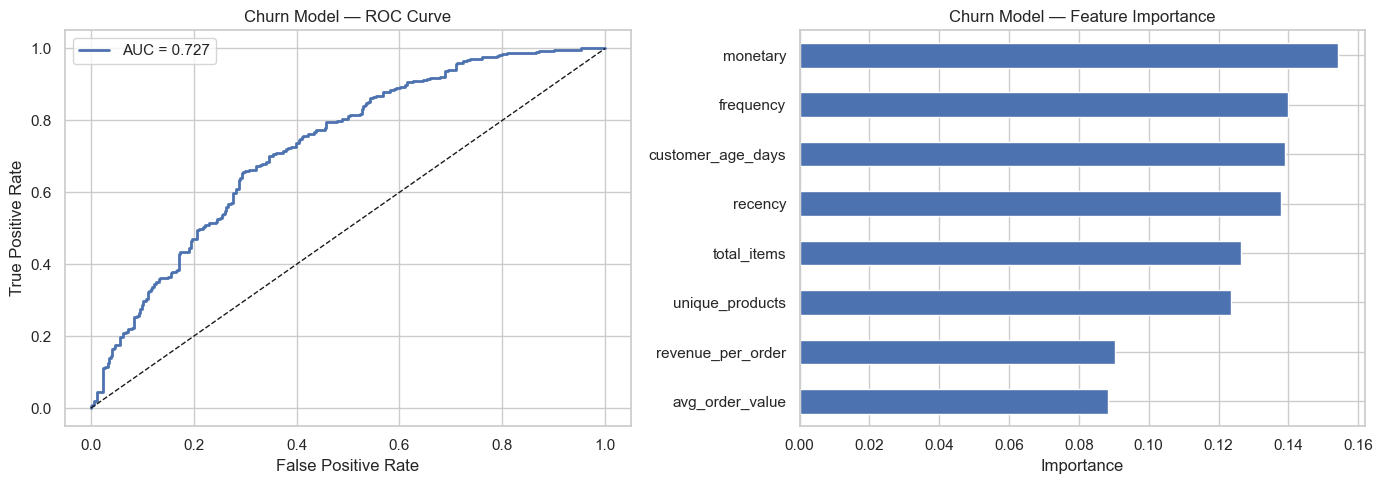

In [10]:
# Churn model plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1], [0,1], "k--", lw=1)
axes[0].set_title("Churn Model — ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Feature Importance
importances = pd.Series(churn_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_title("Churn Model — Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Step 3: Model 2 — CLV Scoring (Regression)

In [11]:
y_clv = np.log1p(features_df["future_revenue"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clv, test_size=0.2, random_state=42
)

clv_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)
clv_model.fit(X_train, y_train)

y_pred_log = clv_model.predict(X_test)
y_pred_act = np.expm1(y_pred_log)
y_test_act = np.expm1(y_test)

print(f"MAE:  £{mean_absolute_error(y_test_act, y_pred_act):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")

MAE:  £362.78
R²:   0.2273


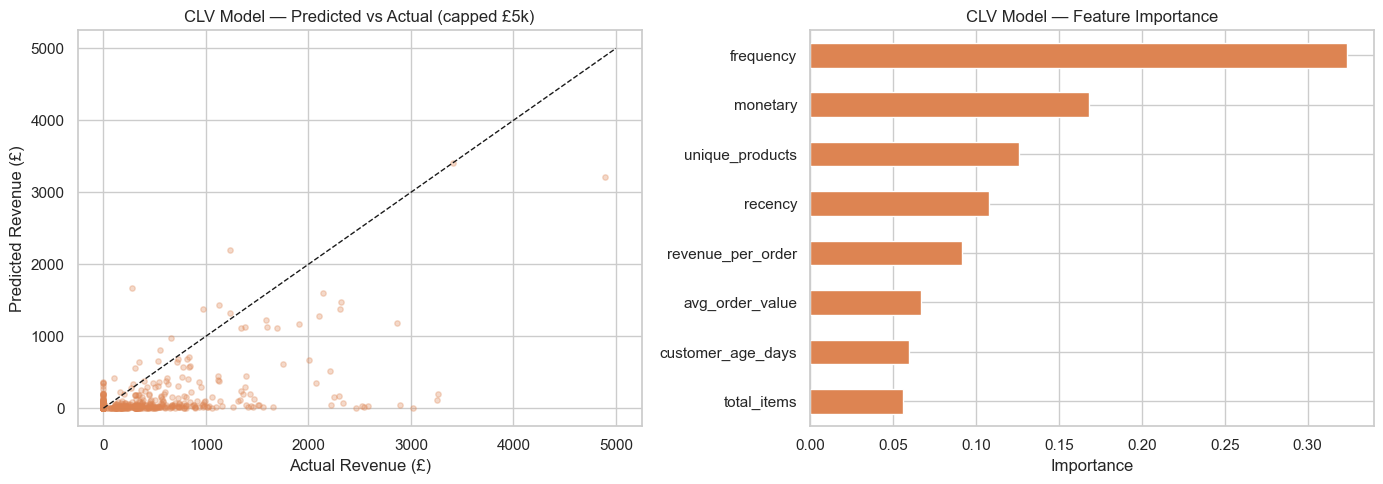

In [12]:
# CLV model plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual (capped at £5k for visibility)
cap = 5000
mask = y_test_act < cap
axes[0].scatter(y_test_act[mask], y_pred_act[mask], alpha=0.3, s=15, color="#DD8452")
axes[0].plot([0, cap], [0, cap], "k--", lw=1)
axes[0].set_title("CLV Model — Predicted vs Actual (capped £5k)")
axes[0].set_xlabel("Actual Revenue (£)")
axes[0].set_ylabel("Predicted Revenue (£)")

# Feature importance
importances = pd.Series(clv_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("CLV Model — Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


## Step 4: Model 3 — Next Purchase Propensity (Classifier)

In [13]:
y_next = features_df["bought_next_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_next, test_size=0.2, random_state=42, stratify=y_next
)

next_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)
next_model.fit(X_train, y_train)

y_pred       = next_model.predict(X_test)
y_pred_proba = next_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Purchase", "Purchase"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

 No Purchase       0.78      0.94      0.85       478
    Purchase       0.59      0.25      0.36       173

    accuracy                           0.76       651
   macro avg       0.69      0.60      0.60       651
weighted avg       0.73      0.76      0.72       651

ROC-AUC: 0.7131


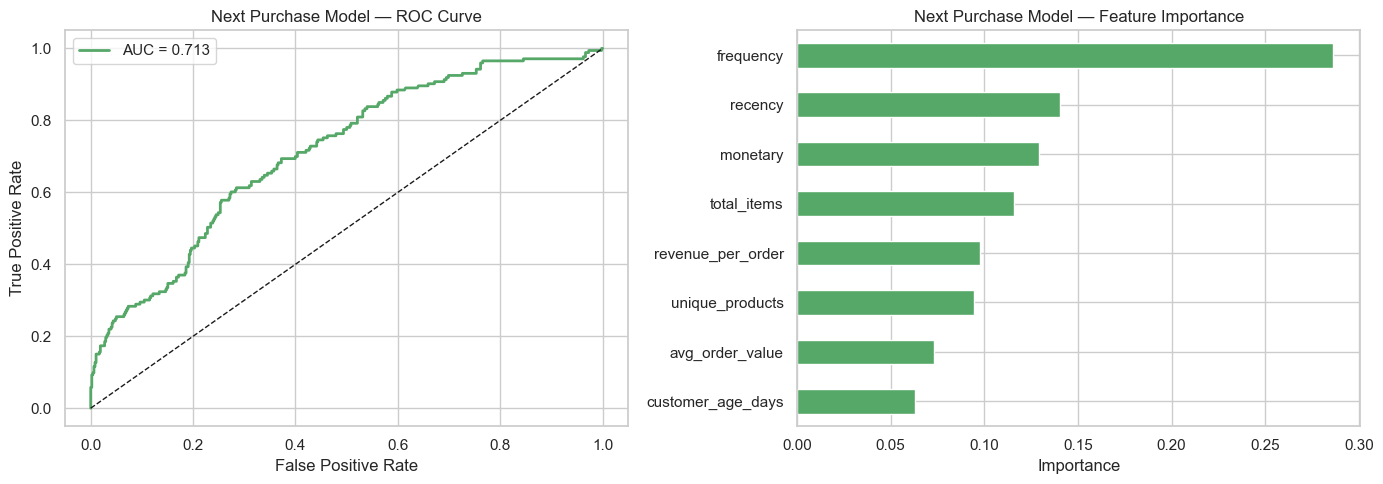

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color="#55A868", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1], [0,1], "k--", lw=1)
axes[0].set_title("Next Purchase Model — ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

importances = pd.Series(next_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Next Purchase Model — Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [15]:
joblib.dump(churn_model, "../src/models/churn_model.pkl")
joblib.dump(clv_model,   "../src/models/clv_model.pkl")
joblib.dump(next_model,  "../src/models/next_purchase_model.pkl")

# Save feature list for use in app
import json
with open("../src/models/feature_names.json", "w") as f:
    json.dump(FEATURES, f)

print("Saved:")
print("  src/models/churn_model.pkl")
print("  src/models/clv_model.pkl")
print("  src/models/next_purchase_model.pkl")
print("  src/models/feature_names.json")

Saved:
  src/models/churn_model.pkl
  src/models/clv_model.pkl
  src/models/next_purchase_model.pkl
  src/models/feature_names.json


1. Churn = AUC 0.727, monetary and frequency are the top predictors, makes intuitive sense

2. CLV = MAE £362, R² 0.23 which means conservative predictions which is actually safer for business use, frequency dominates

3. Next purchase = AUC 0.713, recall on "no purchase" is strong at 0.94, purchase recall is lower (0.25) which is expected with 27/73 imbalance